# Case de Precificação de Crédito

Este estudo tem como objetivo construir uma política de precificação de crédito orientada por dados, a partir de três bases disponibilizadas: **Operações de Crédito**, **Inadimplência** e **Conversão**.

O notebook está organizado em três grandes blocos:

1. **Preparação dos dados** (seções 1 a 9) — leitura, validação, padronização, engenharia de atributos e integração das bases;
2. **Análise exploratória** (seção 10) — identificação das variáveis com maior poder de discriminação da inadimplência;
3. **Construção e avaliação da política de precificação** (seções 11 a 13) — definição da matriz de taxas, estimativa de conversão, avaliação econômica e síntese final.

> 📌 **Nota de execução:** os caminhos das bases apontam para o ambiente local do autor. Para reproduzir os resultados, execute o notebook por completo (*Run All*) após ajustar os caminhos dos arquivos, se necessário.

## 1. Configuração do Ambiente

Nesta etapa são importadas as bibliotecas necessárias para manipulação dos dados, análise estatística e visualização gráfica. Também são definidas as configurações de exibição do pandas, a paleta de cores utilizada em todos os gráficos do case e os caminhos das bases de dados.

In [1]:
# ============================================================
# 1. CONFIGURAÇÃO DO AMBIENTE
# ============================================================

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from cycler import cycler

# Exibição de tabelas
from IPython.display import display

# ------------------------------------------------------------
# Configurações de exibição
# ------------------------------------------------------------

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.width', 160)

# ------------------------------------------------------------
# Identidade visual dos gráficos
# ------------------------------------------------------------
# Paleta institucional (tons de verde, com apoio de azul e âmbar/vermelho
# para leituras de risco) aplicada de forma consistente em todo o notebook.

CORES_SEQ = ["#00703C", "#00995D", "#8DC63F", "#1B4F72", "#5DADE2", "#F9A825"]

CORES_RISCO = {
    "A": "#00995D",   # menor risco
    "B": "#F9A825",   # risco intermediário
    "C": "#C0392B",   # maior risco
}

plt.style.use('default')
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 11,
    "axes.prop_cycle": cycler(color=CORES_SEQ),
})

# ------------------------------------------------------------
# Caminhos das bases
# ------------------------------------------------------------

CAMINHO_OPERACOES = r"C:\Users\anaca\OneDrive\Área de Trabalho\projetos\Sicred\Operacoes_Credito 1.xlsx"
CAMINHO_INADIMPLENCIA = r"C:\Users\anaca\OneDrive\Área de Trabalho\projetos\Sicred\Inadimplencia 1.xlsx"
CAMINHO_CONVERSAO = r"C:\Users\anaca\OneDrive\Área de Trabalho\projetos\Sicred\Conversão 1.xlsx"

print("✅ Ambiente configurado com sucesso!")

✅ Ambiente configurado com sucesso!


## 2. Leitura das Bases de Dados

Nesta etapa são carregadas as três bases disponibilizadas para o desenvolvimento do case:

- **Operações de Crédito:** informações cadastrais das operações concedidas;
- **Inadimplência:** histórico de inadimplência por segmento de clientes;
- **Conversão:** histórico da taxa de conversão de propostas em operações de crédito para diferentes níveis de taxa de juros.

As bases de inadimplência e conversão são carregadas inicialmente em formato bruto (`header=None`), pois possuem cabeçalhos e estrutura matricial que serão tratados nas próximas etapas.

In [2]:
# ============================================================
# 2. LEITURA DAS BASES
# ============================================================

# Base de operações
op_raw = pd.read_excel(
    CAMINHO_OPERACOES,
    sheet_name="Operacoes_Credito"
)

# Base de inadimplência (estrutura original)
inad_raw = pd.read_excel(
    CAMINHO_INADIMPLENCIA,
    sheet_name="Export",
    header=None
)

# Base de conversão (estrutura original)
conv_raw = pd.read_excel(
    CAMINHO_CONVERSAO,
    sheet_name="Conversao",
    header=None
)

# Dimensão das bases carregadas
print(f"Operações: {op_raw.shape}")
print(f"Inadimplência (bruta): {inad_raw.shape}")
print(f"Conversão (bruta): {conv_raw.shape}")

Operações: (29384, 11)
Inadimplência (bruta): (4, 22)
Conversão (bruta): (7, 4)


> ✅ **Resultado:** as três bases foram carregadas com sucesso. As bases de inadimplência e conversão necessitam de tratamento adicional antes de serem integradas à base principal, uma vez que apresentam cabeçalho e estrutura matricial distintos da base de operações.

## 3. Análise Inicial da Base de Operações

Antes do tratamento dos dados, foi realizada uma análise exploratória da base de operações para verificar sua estrutura, tipos de dados e principais variáveis disponíveis. Essa etapa permite identificar possíveis inconsistências, valores ausentes e compreender as características da carteira utilizada no estudo.

In [3]:
# ============================================================
# 3. ANÁLISE INICIAL DA BASE DE OPERAÇÕES
# ============================================================

# Informações gerais da base
op_raw.info()

# Visualização das primeiras linhas
display(op_raw.head())

# Visualização estatística
display(op_raw.describe())

# Visualização de campos nulos
display(op_raw.isnull().sum())

print(f'Registros duplicados: {op_raw.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 29384 entries, 0 to 29383
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Ano_Mes                      29384 non-null  int64  
 1   Id_Operacao                  29384 non-null  int64  
 2   Perfil                       29384 non-null  str    
 3   Nicho                        29384 non-null  str    
 4   Classificacao_Risco_Cliente  29384 non-null  str    
 5   Pre_Fixado_Pos_Fixado        29384 non-null  str    
 6   UF_Cliente                   29384 non-null  str    
 7   Vlr_Financiado               29384 non-null  float64
 8   Prazo_Dias_Operacao          29384 non-null  int64  
 9   Idade_Cliente                29384 non-null  int64  
 10  Tempo_Relacionamento_Anos    29384 non-null  int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 2.5 MB


,Ano_Mes,Id_Operacao,Perfil,Nicho,Classificacao_Risco_Cliente,Pre_Fixado_Pos_Fixado,UF_Cliente,Vlr_Financiado,Prazo_Dias_Operacao,Idade_Cliente,Tempo_Relacionamento_Anos
0,202602,1,Urbano,Gold,B,PRE,GO,"10,277.00",367,64,3
1,202601,2,Urbano,Platinum,A,PRE,RS,"10,284.79",730,42,13
2,202601,3,Urbano,Platinum,A,PRE,RS,"12,428.54",459,23,13
3,202601,4,Urbano,Platinum,B,PRE,BA,"20,653.00",1471,39,12
4,202601,5,Urbano,Gold,B,PRE,RS,"7,500.00",1466,52,12


,Ano_Mes,Id_Operacao,Vlr_Financiado,Prazo_Dias_Operacao,Idade_Cliente,Tempo_Relacionamento_Anos
count,"29,384.00","29,384.00","29,384.00","29,384.00","29,384.00","29,384.00"
mean,"202,601.59","15,032.11","27,693.23",721.62,43.93,7.51
std,0.49,"8,672.54","110,638.16",506.69,15.27,4.60
min,"202,601.00",1.00,20.26,0.00,18.00,0.00
25%,"202,601.00","7,525.75","3,149.00",326.00,31.00,4.00
50%,"202,602.00","15,033.50","7,500.00",721.00,44.00,8.00
75%,"202,602.00","22,539.25","20,000.00","1,096.00",57.00,11.00
max,"202,602.00","30,037.00","4,681,631.00","3,633.00",70.00,15.00


Ano_Mes                        0
Id_Operacao                    0
Perfil                         0
Nicho                          0
Classificacao_Risco_Cliente    0
Pre_Fixado_Pos_Fixado          0
UF_Cliente                     0
Vlr_Financiado                 0
Prazo_Dias_Operacao            0
Idade_Cliente                  0
Tempo_Relacionamento_Anos      0
dtype: int64

Registros duplicados: 0


### Principais observações

- A base contém informações cadastrais das operações de crédito e dos clientes.
- Foram identificadas variáveis relacionadas ao perfil do cliente, características da operação e classificação de risco.
- Não foram observadas inconsistências estruturais que impedissem a continuidade da análise.

### 3.1 Validação da variável Perfil

Foi realizada uma análise da distribuição da variável **Perfil** para identificar possíveis inconsistências cadastrais. Foi identificado um único registro pertencente a uma categoria não prevista pela regra de negócio. Como se tratava de um registro isolado, optou-se por removê-lo antes das análises seguintes, preservando apenas os perfis **Urbano** e **Rural**.

In [4]:
# ============================================================
# Validação da variável Perfil
# ============================================================

# Distribuição dos perfis
print("Distribuição da variável Perfil:")
display(op_raw["Perfil"].value_counts())

# Cruzamento com Nicho para validar a consistência da informação
print("\nPerfil x Nicho:")
display(pd.crosstab(op_raw["Perfil"], op_raw["Nicho"]))

# Remoção de registros com perfis não previstos
qtd_inicial = len(op_raw)

op = (
    op_raw[
        op_raw["Perfil"].isin(["Urbano", "Rural"])
    ]
    .copy()
)

qtd_removida = qtd_inicial - len(op)

print(f"\nRegistros removidos: {qtd_removida}")
print(f"Total de registros após o tratamento: {len(op)}")

Distribuição da variável Perfil:


Perfil
Urbano            21967
Rural              7416
Jonas Sulzbach        1
Name: count, dtype: int64


Perfil x Nicho:


Nicho,Black,Básico,Gold,Platinum
Perfil,,,,
Jonas Sulzbach,0,1,0,0
Rural,0,5541,1246,629
Urbano,2964,6059,7073,5871



Registros removidos: 1
Total de registros após o tratamento: 29383


In [5]:
# ============================================================
# Verificações de Qualidade dos Dados
# ============================================================

# Quantidade de operações duplicadas
duplicados = op['Id_Operacao'].duplicated().sum()

# Valores ausentes
nulos = op.isna().sum()

# Operações com prazo igual a zero
prazo_zero = op[op["Prazo_Dias_Operacao"] == 0]

print(f"Operações duplicadas: {duplicados}")

print("\nValores ausentes por variável:")
display(nulos[nulos > 0])

print(f"\nOperações com prazo igual a zero: {len(prazo_zero)}")

if len(prazo_zero) > 0:
    display(prazo_zero)
else:
    print("Nenhuma inconsistência encontrada.")

Operações duplicadas: 0

Valores ausentes por variável:


Series([], dtype: int64)


Operações com prazo igual a zero: 3


,Ano_Mes,Id_Operacao,Perfil,Nicho,Classificacao_Risco_Cliente,Pre_Fixado_Pos_Fixado,UF_Cliente,Vlr_Financiado,Prazo_Dias_Operacao,Idade_Cliente,Tempo_Relacionamento_Anos
8236,202601,8433,Urbano,Platinum,B,PRE,RS,"4,234.00",0,43,10
24317,202602,24877,Urbano,Black,A,PRE,RS,"10,151.00",0,58,3
28978,202602,29631,Urbano,Black,B,PRE,PR,"4,000.00",0,37,6


> ⚠️ **Resultado da validação:** foram identificadas operações com prazo igual a zero, indicando possíveis inconsistências cadastrais. Esses registros foram sinalizados e tratados na padronização a seguir, sem serem excluídos da base.

## 4. Padronização da Base de Operações

Após a validação da qualidade dos dados, foram realizados ajustes na estrutura da base para facilitar as análises posteriores. As principais transformações realizadas foram:

- criação de um indicador para operações com prazo atípico;
- conversão da variável de competência para o formato de data;
- padronização do nome da variável de classificação de risco;
- conversão das variáveis categóricas para o tipo `category`, visando melhor organização e otimização de memória.

In [6]:
# ============================================================
# 4. PADRONIZAÇÃO DA BASE DE OPERAÇÕES
# ============================================================

# Identifica operações com prazo igual a zero
op["Flag_Prazo_Atipico"] = op["Prazo_Dias_Operacao"] == 0

# Converte a competência para o formato datetime
op["Ano_Mes"] = pd.to_datetime(
    op["Ano_Mes"].astype(str),
    format="%Y%m"
)

# Padroniza o nome da coluna de classificação de risco
op = op.rename(
    columns={
        "Classificacao_Risco_Cliente": "Classificacao_Risco"
    }
)

# Define as variáveis categóricas
colunas_categoricas = [
    "Perfil",
    "Nicho",
    "Classificacao_Risco",
    "Pre_Fixado_Pos_Fixado",
    "UF_Cliente"
]

op[colunas_categoricas] = op[colunas_categoricas].astype("category")

# Verificação da estrutura final da base
display(op.dtypes)

Ano_Mes                      datetime64[us]
Id_Operacao                           int64
Perfil                             category
Nicho                              category
Classificacao_Risco                category
Pre_Fixado_Pos_Fixado              category
UF_Cliente                         category
Vlr_Financiado                      float64
Prazo_Dias_Operacao                   int64
Idade_Cliente                         int64
Tempo_Relacionamento_Anos             int64
Flag_Prazo_Atipico                     bool
dtype: object

> ✅ **Resultado:** a base de operações foi padronizada para as etapas seguintes do estudo. A utilização do tipo `category` reduz o consumo de memória e facilita análises segmentadas, enquanto a padronização dos nomes e formatos garante consistência na integração com as demais bases.

## 5. Engenharia de Atributos

Com o objetivo de facilitar a análise exploratória e a definição da política de precificação, foram criadas variáveis categóricas a partir das características originais das operações. As faixas foram definidas considerando critérios de negócio, permitindo comparar grupos de clientes com características semelhantes e identificar padrões de inadimplência entre diferentes segmentos da carteira.

In [7]:
# ============================================================
# 5. ENGENHARIA DE ATRIBUTOS
# ============================================================

# ------------------------------------------------------------------
# Faixa de Prazo da Operação
# ------------------------------------------------------------------
# Conversão do prazo em dias para faixas aproximadas em meses
op["Faixa_Prazo"] = pd.cut(
    op["Prazo_Dias_Operacao"],
    bins=[-1, 365, 730, 1095, 1460, np.inf],
    labels=[
        "Até 12m",
        "13-24m",
        "25-36m",
        "37-48m",
        "Acima de 48m"
    ]
)

# ------------------------------------------------------------------
# Faixa de Idade do Cliente
# ------------------------------------------------------------------
op["Faixa_Idade"] = pd.cut(
    op["Idade_Cliente"],
    bins=[0, 25, 35, 45, 55, 65, np.inf],
    labels=[
        "Até 25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "Acima de 65"
    ]
)

# ------------------------------------------------------------------
# Faixa de Tempo de Relacionamento
# ------------------------------------------------------------------
op["Faixa_Relacionamento"] = pd.cut(
    op["Tempo_Relacionamento_Anos"],
    bins=[-1, 1, 3, 6, 10, np.inf],
    labels=[
        "Até 1 ano",
        "2-3 anos",
        "4-6 anos",
        "7-10 anos",
        "Acima de 10 anos"
    ]
)

# ------------------------------------------------------------------
# Faixa de Valor Financiado
# ------------------------------------------------------------------
op["Faixa_Valor"] = pd.cut(
    op["Vlr_Financiado"],
    bins=[0, 5_000, 20_000, 50_000, 200_000, np.inf],
    labels=[
        "Até 5k",
        "5k-20k",
        "20k-50k",
        "50k-200k",
        "Acima de 200k"
    ]
)

# Visualização das variáveis criadas
display(
    op[
        [
            "Faixa_Prazo",
            "Faixa_Idade",
            "Faixa_Relacionamento",
            "Faixa_Valor"
        ]
    ].describe()
)

,Faixa_Prazo,Faixa_Idade,Faixa_Relacionamento,Faixa_Valor
count,29383,29383,29383,29383
unique,5,6,5,5
top,Até 12m,36-45,Acima de 10 anos,5k-20k
freq,10177,5631,9226,11696


### Principais observações

As novas variáveis categóricas serão utilizadas nas análises exploratórias para identificar segmentos da carteira com diferentes níveis de inadimplência. Essa abordagem facilita a interpretação dos resultados e permite construir uma política de precificação baseada em grupos de clientes, tornando a estratégia mais aderente ao negócio.

## 6. Preparação da Base de Inadimplência

A base de inadimplência foi disponibilizada em formato matricial, com informações distribuídas em diferentes linhas do cabeçalho. Para possibilitar sua integração com a base de operações, foi necessário reconstruir a tabela em formato tabular, utilizando como dimensões:

- Perfil;
- Nicho;
- Classificação de Risco.

O percentual histórico de inadimplência foi associado a cada combinação dessas variáveis.

In [8]:
# ============================================================
# 6. PREPARAÇÃO DA BASE DE INADIMPLÊNCIA
# ============================================================

# Recupera as informações do cabeçalho da planilha
linha_perfil = inad_raw.iloc[0].ffill()
linha_nicho = inad_raw.iloc[1].ffill()
linha_risco = inad_raw.iloc[2]
linha_inad = inad_raw.iloc[3]

# Reconstrói a base em formato tabular
inad = pd.DataFrame({
    "Perfil": linha_perfil.iloc[1:].values,
    "Nicho": linha_nicho.iloc[1:].values,
    "Classificacao_Risco": linha_risco.iloc[1:].values,
    "Inadimplencia": pd.to_numeric(linha_inad.iloc[1:].values)
})

# Visualização da base tratada
display(inad)

,Perfil,Nicho,Classificacao_Risco,Inadimplencia
0,Rural,Básico,A,0.18
1,Rural,Básico,B,0.22
2,Rural,Básico,C,0.26
3,Rural,Gold,A,0.12
4,Rural,Gold,B,0.18
5,Rural,Gold,C,0.20
6,Rural,Platinum,A,0.03
7,Rural,Platinum,B,0.07
8,Rural,Platinum,C,0.09
9,Urbano,Básico,A,0.28


In [9]:
print(inad.info())

display(inad.head())

display(inad.describe())

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Perfil               21 non-null     str    
 1   Nicho                21 non-null     str    
 2   Classificacao_Risco  21 non-null     str    
 3   Inadimplencia        21 non-null     float64
dtypes: float64(1), str(3)
memory usage: 804.0 bytes
None


,Perfil,Nicho,Classificacao_Risco,Inadimplencia
0,Rural,Básico,A,0.18
1,Rural,Básico,B,0.22
2,Rural,Básico,C,0.26
3,Rural,Gold,A,0.12
4,Rural,Gold,B,0.18


,Inadimplencia
count,21.00
mean,0.19
std,0.11
min,0.03
25%,0.10
50%,0.18
75%,0.26
max,0.44


> ✅ **Resultado do tratamento:** a base de inadimplência passou a possuir uma estrutura tabular, permitindo sua integração com a base de operações por meio das variáveis **Perfil**, **Nicho** e **Classificação de Risco**. Essa transformação foi essencial para incorporar o percentual histórico de inadimplência às operações da carteira.

## 7. Preparação da Base de Conversão

A base de conversão foi disponibilizada em formato matricial, apresentando as taxas de conversão para diferentes combinações de **taxa de juros** e **classificação de risco**. Para facilitar a integração com a política de precificação proposta, a base foi convertida para o formato **long**, no qual cada linha representa uma combinação única de:

- Taxa de Juros Mensal;
- Classificação de Risco;
- Taxa de Conversão.

In [10]:
# ============================================================
# 7. PREPARAÇÃO DA BASE DE CONVERSÃO
# ============================================================

# Recupera as classificações de risco presentes no cabeçalho
cabecalho_risco = conv_raw.iloc[0, 1:].values

# Reconstrói a tabela de conversão
conv = conv_raw.iloc[2:].copy()

conv.columns = [
    "Taxa_Juros_Mensal",
    *cabecalho_risco
]

# Ajusta o tipo da variável de taxa
conv["Taxa_Juros_Mensal"] = pd.to_numeric(
    conv["Taxa_Juros_Mensal"]
)

# Converte a tabela do formato wide para long
conv_long = conv.melt(
    id_vars="Taxa_Juros_Mensal",
    var_name="Classificacao_Risco",
    value_name="Taxa_Conversao"
)

# Ajusta o tipo da taxa de conversão
conv_long["Taxa_Conversao"] = pd.to_numeric(
    conv_long["Taxa_Conversao"]
)

# Ordena a base para facilitar consultas e integração
conv_long = (
    conv_long
    .sort_values(
        ["Classificacao_Risco", "Taxa_Juros_Mensal"]
    )
    .reset_index(drop=True)
)

# Visualização da base tratada
display(conv_long)

,Taxa_Juros_Mensal,Classificacao_Risco,Taxa_Conversao
0,0.02,A,0.39
1,0.03,A,0.26
2,0.04,A,0.19
3,0.05,A,0.14
4,0.06,A,0.10
5,0.02,B,0.55
6,0.03,B,0.43
7,0.04,B,0.39
8,0.05,B,0.35
9,0.06,B,0.24


> ✅ **Resultado do tratamento:** a base de conversão passou a representar cada combinação de **Classificação de Risco** e **Taxa de Juros Mensal** em uma única linha, permitindo estimar a conversão esperada da política proposta a partir do histórico disponibilizado no case.

## 8. Validação das Chaves de Integração

Antes da integração das bases de operações e inadimplência, foi realizada uma validação das chaves de relacionamento. O objetivo dessa etapa foi garantir que todas as combinações de **Perfil**, **Nicho** e **Classificação de Risco** existentes na base de operações possuíam um correspondente na base de inadimplência, evitando perdas de informação durante o processo de integração.

In [11]:
# ============================================================
# 8. VALIDAÇÃO DAS CHAVES DE INTEGRAÇÃO
# ============================================================

# Combinações únicas existentes na base de operações
chaves_operacoes = set(
    op[
        ["Perfil", "Nicho", "Classificacao_Risco"]
    ]
    .drop_duplicates()
    .apply(tuple, axis=1)
)

# Combinações existentes na base de inadimplência
chaves_inad = set(
    inad[
        ["Perfil", "Nicho", "Classificacao_Risco"]
    ]
    .apply(tuple, axis=1)
)

# Identifica combinações sem correspondência
faltantes = chaves_operacoes - chaves_inad

print(f"Combinações sem correspondência: {len(faltantes)}")

if faltantes:
    print("\nCombinações não encontradas:")
    for chave in sorted(faltantes):
        print(chave)
else:
    print("✅ Todas as combinações possuem correspondência na base de inadimplência.")

Combinações sem correspondência: 0
✅ Todas as combinações possuem correspondência na base de inadimplência.


> ✅ **Resultado da validação:** todas as combinações de **Perfil**, **Nicho** e **Classificação de Risco** presentes na base de operações possuem correspondência na base de inadimplência. Dessa forma, foi possível realizar a integração das bases sem risco de perda de informações ou geração de valores ausentes.

## 9. Integração das Bases

Após a validação das chaves de relacionamento, a base de operações foi integrada à base de inadimplência, utilizando as variáveis **Perfil**, **Nicho** e **Classificação de Risco**. Foi utilizado um relacionamento do tipo **many-to-one**, garantindo que cada operação recebesse o percentual histórico de inadimplência correspondente ao seu segmento.

In [12]:
# ============================================================
# 9. INTEGRAÇÃO DAS BASES
# ============================================================

# Integra a base de operações com a base de inadimplência
op_tratado = op.merge(
    inad,
    on=["Perfil", "Nicho", "Classificacao_Risco"],
    how="left",
    validate="many_to_one"
)

# Validação da integração
nulos_inad = op_tratado["Inadimplencia"].isna().sum()

print(f"Operações sem percentual de inadimplência: {nulos_inad}")

# Visualização da base integrada
display(op_tratado.head())

Operações sem percentual de inadimplência: 0


,Ano_Mes,Id_Operacao,Perfil,Nicho,Classificacao_Risco,Pre_Fixado_Pos_Fixado,UF_Cliente,Vlr_Financiado,Prazo_Dias_Operacao,Idade_Cliente,Tempo_Relacionamento_Anos,Flag_Prazo_Atipico,Faixa_Prazo,Faixa_Idade,Faixa_Relacionamento,Faixa_Valor,Inadimplencia
0,2026-02-01,1,Urbano,Gold,B,PRE,GO,"10,277.00",367,64,3,False,13-24m,56-65,2-3 anos,5k-20k,0.27
1,2026-01-01,2,Urbano,Platinum,A,PRE,RS,"10,284.79",730,42,13,False,13-24m,36-45,Acima de 10 anos,5k-20k,0.10
2,2026-01-01,3,Urbano,Platinum,A,PRE,RS,"12,428.54",459,23,13,False,13-24m,Até 25,Acima de 10 anos,5k-20k,0.10
3,2026-01-01,4,Urbano,Platinum,B,PRE,BA,"20,653.00",1471,39,12,False,Acima de 48m,36-45,Acima de 10 anos,20k-50k,0.14
4,2026-01-01,5,Urbano,Gold,B,PRE,RS,"7,500.00",1466,52,12,False,Acima de 48m,46-55,Acima de 10 anos,5k-20k,0.27


> ✅ **Resultado da integração:** a integração foi concluída com sucesso. Todas as operações da carteira receberam o respectivo percentual histórico de inadimplência, não sendo identificados valores ausentes após o merge. A partir desta etapa, a base consolidada (`op_tratado`) passou a concentrar todas as informações necessárias para as análises exploratórias e para a construção da política de precificação.

## 10. Análise Exploratória da Carteira

Após a integração das bases, foi realizada uma análise exploratória com o objetivo de identificar quais características da carteira apresentavam maior capacidade de discriminar a inadimplência.

Foram avaliadas variáveis relacionadas ao perfil do cliente e às características das operações, buscando identificar os principais direcionadores de risco que poderiam ser utilizados na construção da política de precificação.

### 10.1 Inadimplência Média por Segmento

O primeiro passo da análise exploratória é comparar a inadimplência média entre as categorias de cada variável candidata, junto da quantidade de operações e do valor de carteira associado a cada segmento.

In [13]:
# ============================================================
# 10.1 INADIMPLÊNCIA MÉDIA POR SEGMENTO
# ============================================================

# Variáveis analisadas
variaveis = [
    "Perfil",
    "Nicho",
    "Classificacao_Risco",
    "Faixa_Valor",
    "Faixa_Prazo",
    "Faixa_Relacionamento",
    "Faixa_Idade"
]

# Avaliação da inadimplência média por variável
for var in variaveis:

    print(f"\n{'='*70}")
    print(f"Inadimplência média por {var}")
    print(f"{'='*70}")

    resumo = (
        op_tratado
        .groupby(var, observed=True)
        .agg(
            Quantidade_Operacoes=("Id_Operacao", "count"),
            Inadimplencia_Media=("Inadimplencia", "mean"),
            Valor_Carteira=("Vlr_Financiado", "sum")
        )
        .sort_values(
            "Inadimplencia_Media",
            ascending=False
        )
        .round(4)
    )

    display(resumo)


Inadimplência média por Perfil


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Perfil,,,
Urbano,21967,0.22,"257,685,442.73"
Rural,7416,0.16,"556,035,234.70"



Inadimplência média por Nicho


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Nicho,,,
Básico,11600,0.28,"193,375,025.70"
Gold,8319,0.23,"203,760,683.78"
Platinum,6500,0.11,"319,235,298.47"
Black,2964,0.07,"97,349,669.48"



Inadimplência média por Classificacao_Risco


...

,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Faixa_Prazo,,,
13-24m,6404,0.22,"109,700,752.45"
25-36m,5433,0.20,"128,520,663.64"
37-48m,4620,0.20,"198,450,412.00"
Acima de 48m,2749,0.20,"121,695,082.24"
Até 12m,10177,0.20,"255,353,767.10"



Inadimplência média por Faixa_Relacionamento


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Faixa_Relacionamento,,,
4-6 anos,5430,0.21,"141,574,299.91"
Acima de 10 anos,9226,0.21,"261,517,493.85"
Até 1 ano,3679,0.21,"105,640,926.44"
2-3 anos,3630,0.20,"102,173,329.90"
7-10 anos,7418,0.20,"202,814,627.33"



Inadimplência média por Faixa_Idade


,Quantidade_Operacoes,Inadimplencia_Media,Valor_Carteira
Faixa_Idade,,,
36-45,5631,0.21,"154,427,395.70"
26-35,5480,0.21,"145,018,723.21"
Até 25,4500,0.21,"123,562,642.73"
56-65,5588,0.21,"151,482,783.15"
46-55,5480,0.20,"162,456,878.75"
Acima de 65,2704,0.20,"76,772,253.89"


> 🔍 **Interpretação inicial:** as tabelas acima permitem comparar o comportamento da inadimplência entre os diferentes segmentos da carteira. Nesta etapa ainda não são definidas regras de precificação; o objetivo é identificar quais variáveis apresentam maior capacidade de diferenciar o risco de crédito e, portanto, possuem potencial para compor a política proposta.

### 10.2 Análise Gráfica da Inadimplência

Com o objetivo de facilitar a interpretação dos resultados, foram construídos gráficos apresentando a inadimplência média para cada variável analisada. A representação gráfica complementa a análise tabular, permitindo identificar visualmente quais segmentos apresentam maior concentração de risco e quais variáveis possuem maior capacidade de discriminar a inadimplência.

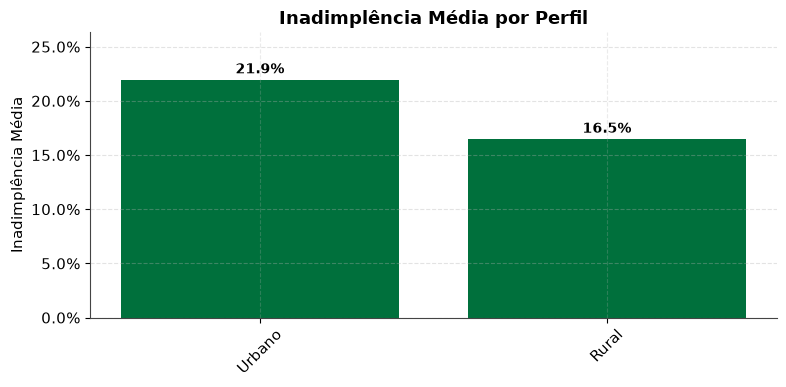

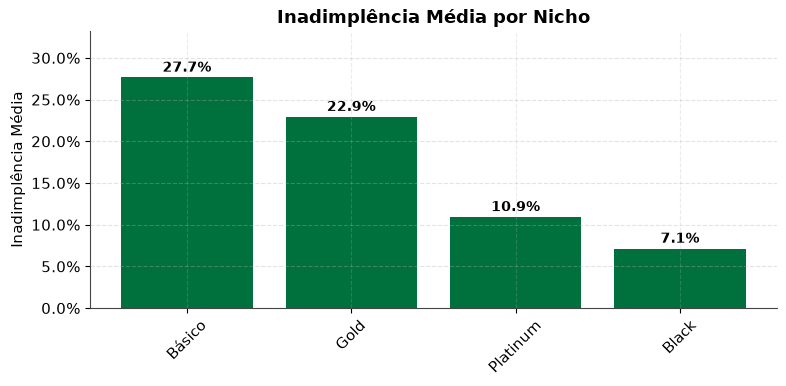

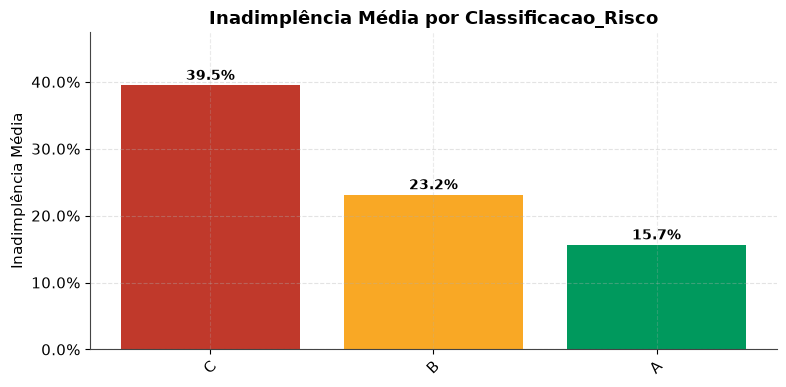

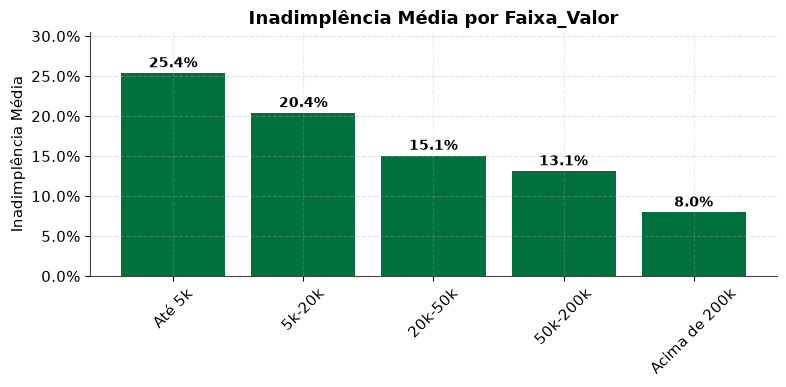

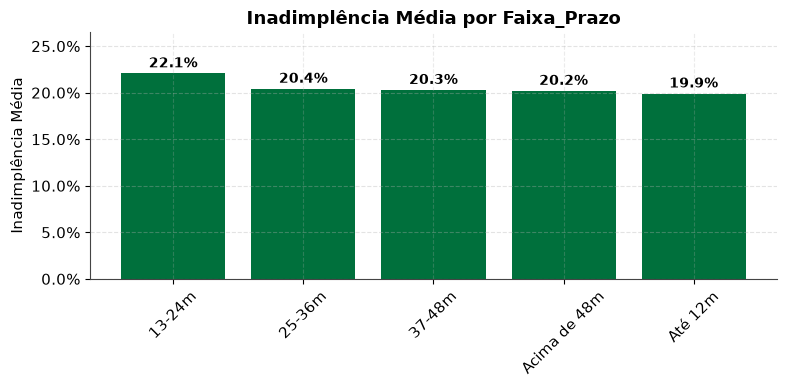

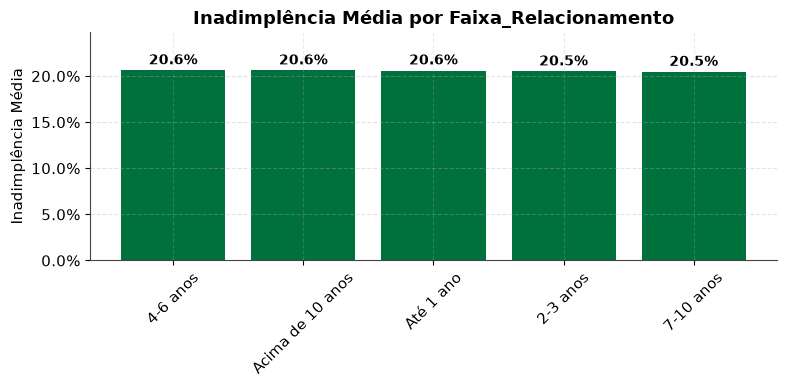

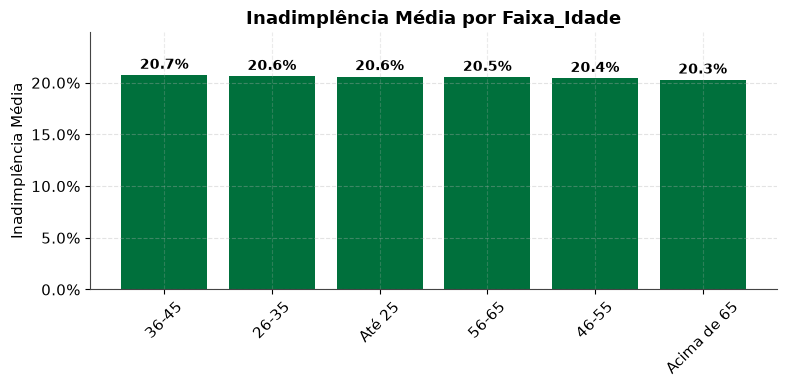

In [14]:
# ============================================================
# 10.2 ANÁLISE GRÁFICA DA INADIMPLÊNCIA
# ============================================================

for var in variaveis:

    # Calcula a inadimplência média por categoria
    resumo = (
        op_tratado
        .groupby(var, observed=True)["Inadimplencia"]
        .mean()
        .sort_values(ascending=False)
    )

    # Usa a paleta de risco quando a variável for Classificação de Risco
    if var == "Classificacao_Risco":
        cores = [CORES_RISCO.get(cat, "#00995D") for cat in resumo.index.astype(str)]
    else:
        cores = CORES_SEQ[0]

    fig, ax = plt.subplots(figsize=(8, 4))

    barras = ax.bar(
        resumo.index.astype(str),
        resumo.values,
        color=cores
    )

    # --------------------------------------------------------
    # Configuração do gráfico
    # --------------------------------------------------------

    ax.set_title(
        f'Inadimplência Média por {var}',
        fontsize=13,
        fontweight='bold'
    )

    ax.set_ylabel('Inadimplência Média')

    ax.yaxis.set_major_formatter(
        PercentFormatter(1)
    )

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.35
    )

    plt.xticks(rotation=45)

    # --------------------------------------------------------
    # Percentual sobre as barras
    # --------------------------------------------------------

    for barra in barras:

        altura = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width()/2,
            altura + 0.003,
            f'{altura:.1%}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    ax.set_ylim(
        0,
        resumo.max()*1.20
    )

    plt.tight_layout()

    plt.show()

### 10.3 Principais Achados da Análise Exploratória

A análise exploratória demonstrou que a inadimplência não se distribui de forma homogênea entre os diferentes segmentos da carteira. Os principais resultados observados foram:

- A **Classificação de Risco** apresentou o maior poder de discriminação da inadimplência, confirmando sua relevância como principal direcionador da política de precificação.
- A **Faixa de Valor Financiado** também apresentou diferenças relevantes de inadimplência, mantendo comportamento distinto mesmo dentro de uma mesma classificação de risco.
- As variáveis **Perfil**, **Nicho**, **Prazo**, **Idade** e **Tempo de Relacionamento** apresentaram menor capacidade de diferenciação da inadimplência e, por esse motivo, não foram utilizadas como direcionadores da política proposta.

Com base nesses resultados, definiu-se que a política de precificação seria construída considerando duas dimensões principais: **Classificação de Risco** e **Faixa de Valor Financiado**.

### 10.4 Poder de Discriminação das Variáveis

Além da análise gráfica, foi calculada a amplitude da inadimplência para cada variável analisada. A diferença entre a maior e a menor inadimplência permite avaliar o poder de discriminação de cada variável, auxiliando na seleção dos atributos que comporão a política de precificação.

In [15]:
# ============================================================
# 10.4 PODER DE DISCRIMINAÇÃO DAS VARIÁVEIS
# ============================================================

resultado = []

for var in variaveis:

    resumo = (
        op_tratado
        .groupby(var, observed=True)["Inadimplencia"]
        .mean()
    )

    resultado.append({
        "Variável": var,
        "Maior Inadimplência": resumo.max(),
        "Menor Inadimplência": resumo.min(),
        "Diferença": resumo.max() - resumo.min()
    })

resultado = (
    pd.DataFrame(resultado)
    .sort_values("Diferença", ascending=False)
)

display(
    resultado.style
    .format({
        "Maior Inadimplência": "{:.2%}",
        "Menor Inadimplência": "{:.2%}",
        "Diferença": "{:.2%}"
    })
    .background_gradient(subset=["Diferença"], cmap="Greens")
)

,Variável,Maior Inadimplência,Menor Inadimplência,Diferença
2,Classificacao_Risco,39.51%,15.66%,23.85%
1,Nicho,27.66%,7.14%,20.51%
3,Faixa_Valor,25.39%,7.98%,17.41%
0,Perfil,21.94%,16.46%,5.48%
4,Faixa_Prazo,22.07%,19.90%,2.17%
6,Faixa_Idade,20.73%,20.27%,0.46%
5,Faixa_Relacionamento,20.62%,20.45%,0.17%


Complementarmente, avalia-se o cruzamento entre **Classificação de Risco** e **Nicho** — a segunda variável com maior poder de discriminação isolado (≈20 p.p. de diferença) — para verificar se ela adiciona informação relevante além da já capturada pela Classificação de Risco.

In [16]:
(
    op_tratado
    .groupby(
        ["Classificacao_Risco", "Nicho"],
        observed=True
    )
    .agg(
        Operacoes=("Id_Operacao", "count"),
        Inadimplencia=("Inadimplencia", "mean")
    )
    .round(4)
)

Operacoes  Inadimplencia
Classificacao_Risco Nicho                             
A                   Black          1901           0.06
                    Básico         6061           0.21
                    Gold           4446           0.19
                    Platinum       3739           0.09
B                   Black          1015           0.09
                    Básico         3398           0.31
                    Gold           3558           0.27
                    Platinum       2532           0.13
C                   Black            48           0.11
                    Básico         2141           0.43
                    Gold            315           0.34
                    Platinum        229           0.23

### Conclusão e Seleção das Variáveis da Política de Precificação

A análise exploratória demonstrou que **Classificação de Risco**, **Nicho** e **Faixa de Valor** apresentaram maior capacidade de discriminar a inadimplência da carteira.

Entretanto, buscando uma política de precificação **simples, transparente e operacionalmente viável**, optou-se por utilizar apenas a **Classificação de Risco** e a **Faixa de Valor** como direcionadores da política proposta.

A **Classificação de Risco** foi definida como principal variável por representar a avaliação consolidada do risco de crédito da operação. A **Faixa de Valor** foi incorporada por demonstrar capacidade adicional de discriminar a inadimplência mesmo dentro de uma mesma classificação de risco, permitindo um refinamento da precificação.

Embora o **Nicho** também tenha apresentado diferenças relevantes de inadimplência, sua incorporação aumentaria significativamente a complexidade da política, elevando o número de combinações de taxas e dificultando sua implementação e manutenção. Dessa forma, optou-se por mantê-lo como uma **variável de monitoramento**, podendo ser considerado em futuras revisões da política, caso estudos adicionais demonstrem ganho relevante em rentabilidade ou capacidade preditiva.

### 10.5 Avaliação da Faixa de Valor dentro da Classificação de Risco

Após identificar a **Classificação de Risco** e a **Faixa de Valor** como variáveis relevantes, foi realizada uma análise conjunta para verificar se a Faixa de Valor continuava diferenciando a inadimplência dentro de uma mesma classificação de risco. Essa análise permite avaliar se a Faixa de Valor agrega informação além daquela já capturada pela Classificação de Risco, justificando sua utilização como segundo direcionador da política de precificação.

In [17]:
# ============================================================
# 10.5 AVALIAÇÃO CONJUNTA: RISCO x FAIXA DE VALOR
# ============================================================

resumo_risco_valor = (
    op_tratado
    .groupby(
        ["Classificacao_Risco", "Faixa_Valor"],
        observed=True
    )
    .agg(
        Operacoes=("Id_Operacao", "count"),
        Inadimplencia=("Inadimplencia", "mean")
    )
    .round(4)
)

display(resumo_risco_valor)

Operacoes  Inadimplencia
Classificacao_Risco Faixa_Valor                            
A                   Até 5k              4002           0.19
                    5k-20k              6602           0.16
                    20k-50k             3191           0.13
                    50k-200k            1848           0.12
                    Acima de 200k        504           0.07
B                   Até 5k              4718           0.25
                    5k-20k              4264           0.23
                    20k-50k             1071           0.18
                    50k-200k             363           0.16
                    Acima de 200k         87           0.11
C                   Até 5k              1681           0.42
                    5k-20k               830           0.38
                    20k-50k              157           0.31
                    50k-200k              59           0.30
                    Acima de 200k          6           0.18

> 💡 **Interpretação:** observou-se que a **Faixa de Valor** continua diferenciando a inadimplência mesmo dentro de uma mesma classificação de risco. Em todos os níveis de risco, as operações de menor valor apresentaram maiores percentuais de inadimplência, enquanto operações de maior valor apresentaram comportamento mais favorável. Esse resultado indica que a Faixa de Valor agrega informação relevante à Classificação de Risco, justificando sua utilização como variável complementar na política de precificação proposta.

### 10.6 Representatividade da Faixa de Valor na Carteira

Além de diferenciar a inadimplência, uma variável utilizada em uma política de precificação deve apresentar representatividade suficiente na carteira para justificar sua utilização. Nesta etapa foi analisada a distribuição das operações e do valor financeiro da carteira por **Classificação de Risco** e **Faixa de Valor**, permitindo avaliar simultaneamente:

- percentual histórico de inadimplência;
- quantidade de operações;
- participação no valor total da carteira.

In [18]:
# ============================================================
# 10.6 REPRESENTATIVIDADE DA FAIXA DE VALOR
# ============================================================

# Resumo por classificação de risco e faixa de valor
resumo = (
    op_tratado
    .groupby(
        ["Classificacao_Risco", "Faixa_Valor"],
        observed=True
    )
    .agg(
        Operacoes=("Id_Operacao", "count"),
        Valor_Carteira=("Vlr_Financiado", "sum"),
        Inadimplencia=("Inadimplencia", "mean")
    )
    .reset_index()
)

# Participação das operações na carteira
resumo["% Operacoes"] = (
    resumo["Operacoes"] /
    resumo["Operacoes"].sum()
)

# Participação financeira na carteira
resumo["% Valor Carteira"] = (
    resumo["Valor_Carteira"] /
    resumo["Valor_Carteira"].sum()
)

# Organização da tabela
resumo = resumo.sort_values(
    ["Classificacao_Risco", "Faixa_Valor"]
)

display(
    resumo.style.format({
        "Valor_Carteira": "R$ {:,.0f}",
        "Inadimplencia": "{:.2%}",
        "% Operacoes": "{:.2%}",
        "% Valor Carteira": "{:.2%}"
    })
)

,Classificacao_Risco,Faixa_Valor,Operacoes,Valor_Carteira,Inadimplencia,% Operacoes,% Valor Carteira
0,A,Até 5k,4002,"R$ 10,636,403",18.97%,13.62%,1.31%
1,A,5k-20k,6602,"R$ 68,995,672",16.39%,22.47%,8.48%
2,A,20k-50k,3191,"R$ 101,706,444",13.40%,10.86%,12.50%
3,A,50k-200k,1848,"R$ 172,928,812",12.05%,6.29%,21.25%
4,A,Acima de 200k,504,"R$ 268,064,354",7.26%,1.72%,32.94%
5,B,Até 5k,4718,"R$ 11,701,572",25.06%,16.06%,1.44%
6,B,5k-20k,4264,"R$ 40,342,052",23.27%,14.51%,4.96%
7,B,20k-50k,1071,"R$ 32,623,847",17.75%,3.64%,4.01%
8,B,50k-200k,363,"R$ 32,805,085",15.83%,1.24%,4.03%
9,B,Acima de 200k,87,"R$ 50,637,457",11.43%,0.30%,6.22%


Consolidando a mesma leitura por **Faixa de Valor**, de forma agregada e independente da Classificação de Risco:

In [19]:
(
    op_tratado
    .groupby('Faixa_Valor', observed=True)
    .agg(
        Operacoes=('Id_Operacao', 'count'),
        Inadimplencia=('Inadimplencia', 'mean')
    )
    .assign(
        Representatividade=lambda x:
        x['Operacoes'] / x['Operacoes'].sum()
    )
    .sort_values('Inadimplencia', ascending=False)
    .style.format({
        'Inadimplencia': '{:.2%}',
        'Representatividade': '{:.2%}'
    })
)

,Operacoes,Inadimplencia,Representatividade
Faixa_Valor,,,
Até 5k,10401,25.39%,35.40%
5k-20k,11696,20.41%,39.81%
20k-50k,4419,15.07%,15.04%
50k-200k,2270,13.13%,7.73%
Acima de 200k,597,7.98%,2.03%


> 🎯 **Principais achados:** a análise confirmou que a **Faixa de Valor** não apenas diferencia a inadimplência dentro de cada classificação de risco, como também apresenta elevada representatividade na carteira.
>
> - As operações de **até R$ 20 mil** concentram aproximadamente **75% das operações** (faixas "Até 5k" + "5k-20k"), além de apresentarem os maiores percentuais de inadimplência em todas as classificações de risco.
> - As operações de maior valor apresentaram menor inadimplência, porém representam uma parcela significativamente menor da quantidade de operações, embora concentrem maior participação financeira da carteira.
>
> Esses resultados reforçam a utilização da **Faixa de Valor** como variável complementar na política de precificação, permitindo diferenciar segmentos relevantes tanto sob a perspectiva do risco quanto do impacto financeiro.

## 11. Construção da Política de Precificação

Com base nos direcionadores identificados na análise exploratória — **Classificação de Risco** e **Faixa de Valor** — foi construída a política de precificação do case. Esta etapa contempla a definição das premissas financeiras, o agrupamento das faixas de valor, a construção da matriz de taxas e a estimativa dos impactos em conversão e resultado esperado.

### 11.1 Premissas Financeiras

Conforme estabelecido no enunciado do case, a política de precificação deve contemplar três componentes:

- custo de funding;
- custo esperado do risco de crédito;
- spread de rentabilidade.

Como premissa, foi considerado um custo de funding equivalente a **100% do CDI**, assumindo uma taxa anual de **15%**, convertida para taxa efetiva mensal.

Para o custo do risco, utilizou-se a inadimplência histórica da carteira, considerando a hipótese de crescimento linear da inadimplência ao longo de 24 meses, conforme informado no exercício.

In [20]:
# ============================================================
# 11.1 PREMISSAS FINANCEIRAS
# ============================================================

# Funding mensal (100% CDI - premissa de 15% a.a.)
funding = (1 + 0.15) ** (1/12) - 1

# Aproximação do custo mensal do risco (inadimplência amortizada
# linearmente ao longo de 24 meses, conforme premissa do case)
op_tratado["Custo_Risco_Mensal"] = (
    op_tratado["Inadimplencia"] / 24
)

print(f"Funding mensal considerado: {funding:.2%}")

Funding mensal considerado: 1.17%


### 11.2 Agrupamento das Faixas de Valor

Para manter a política simples e operacionalmente viável, as cinco faixas de valor identificadas na análise exploratória foram consolidadas em três grupos. Essa simplificação reduz a complexidade da matriz de precificação sem perder a capacidade de diferenciar segmentos com comportamentos distintos de inadimplência.

In [21]:
# ============================================================
# 11.2 AGRUPAMENTO DAS FAIXAS DE VALOR
# ============================================================

def grupo_valor(x):

    if x in ["Até 5k", "5k-20k"]:
        return "Até 20k"

    elif x == "20k-50k":
        return "20k-50k"

    else:
        return "Acima 50k"


op_tratado["Grupo_Valor"] = (
    op_tratado["Faixa_Valor"]
    .apply(grupo_valor)
)

display(
    op_tratado["Grupo_Valor"]
    .value_counts()
    .rename("Operações")
    .to_frame()
)

,Operações
Grupo_Valor,
Até 20k,22097
20k-50k,4419
Acima 50k,2867


### 11.3 Definição da Matriz de Precificação

Com base na análise exploratória, foi construída uma matriz de taxas considerando:

- Classificação de Risco;
- Grupo de Valor.

As taxas foram definidas buscando equilibrar:

- risco esperado;
- competitividade;
- conversão estimada;
- simplicidade operacional.

In [22]:
# ============================================================
# 11.3 MATRIZ DE PRECIFICAÇÃO
# ============================================================

politica = {

    ("A", "Até 20k"): 0.03,
    ("A", "20k-50k"): 0.02,
    ("A", "Acima 50k"): 0.02,

    ("B", "Até 20k"): 0.04,
    ("B", "20k-50k"): 0.03,
    ("B", "Acima 50k"): 0.03,

    ("C", "Até 20k"): 0.06,
    ("C", "20k-50k"): 0.05,
    ("C", "Acima 50k"): 0.05

}

display(
    pd.Series(politica)
    .rename("Taxa Proposta")
    .to_frame()
    .style.format("{:.0%}")
)

### 11.4 Aplicação da Política

Após definida a matriz de precificação, cada operação recebeu a taxa correspondente ao seu segmento de risco e grupo de valor.

In [27]:
# ============================================================
# 11.4 APLICAÇÃO DA POLÍTICA
# ============================================================

op_tratado["Taxa_Nova"] = (

    op_tratado[
        ["Classificacao_Risco", "Grupo_Valor"]
    ]

    .apply(tuple, axis=1)

    .map(politica)

)

### 11.5 Estimativa da Conversão Esperada

Para estimar o impacto comercial da política proposta, cada operação foi associada à taxa histórica de conversão correspondente à sua classificação de risco e à taxa de juros atribuída. A base histórica de conversão foi utilizada como aproximação do comportamento esperado dos clientes diante da nova política.

In [32]:
# ============================================================
# 11.5 ESTIMATIVA DA CONVERSÃO
# ============================================================

op_tratado = op_tratado.merge(

    conv_long,

    left_on=[
        "Classificacao_Risco",
        "Taxa_Nova"
    ],

    right_on=[
        "Classificacao_Risco",
        "Taxa_Juros_Mensal"
    ],

    how="left"

)

### 11.6 Avaliação Econômica da Política

Como indicador simplificado de desempenho, foi estimado o resultado esperado da política considerando:

- taxa de juros proposta;
- custo de funding;
- perda esperada com inadimplência;
- conversão estimada.

Essa métrica permite comparar o desempenho esperado dos diferentes segmentos da política proposta.

In [34]:
# ============================================================
# 11.6 RESULTADO ESPERADO
# ============================================================


assert "Taxa_Conversao" in op_tratado.columns, (
    "Coluna 'Taxa_Conversao' não encontrada em op_tratado. "
    "Execute novamente a seção 11.5 (merge com conv_long) antes desta célula, "
    "ou use 'Kernel > Restart & Run All' para rodar o notebook em sequência."
)

op_tratado["Resultado_Esperado"] = (

    (

        op_tratado["Taxa_Nova"]

        - funding

        - op_tratado["Inadimplencia"]

    )

    * op_tratado["Taxa_Conversao"]

)

## 12. Resultados da Política Proposta

Com a política de precificação aplicada a toda a carteira, esta seção reúne a leitura executiva dos resultados sob quatro ângulos complementares:

1. **Volume** — como as operações se distribuem entre as novas taxas;
2. **Conversão** — a adesão esperada dos clientes por classificação de risco;
3. **Resultado econômico** — o retorno esperado de cada segmento, líquido de funding e risco;
4. **Consolidação** — a matriz final de taxas e um painel-resumo por faixa de taxa.

O objetivo é conectar os números aos achados da análise exploratória (seção 10), verificando se a política proposta é, ao mesmo tempo, **aderente ao risco**, **competitiva** e **operacionalmente simples**.

### 12.1 Distribuição da Carteira pela Nova Taxa

O primeiro olhar é sobre volume: em qual taxa a carteira se concentra após a aplicação da política? Uma política saudável deve concentrar o maior volume de operações nas faixas de menor risco, refletindo o perfil predominante da base atual (majoritariamente classificações A e B, conforme visto na seção 10).

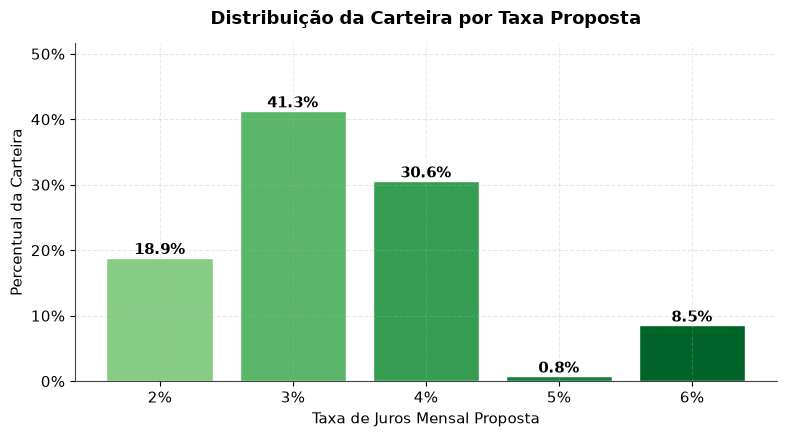

In [35]:
# ============================================================
# 12.1 DISTRIBUIÇÃO DA CARTEIRA PELA NOVA TAXA
# ============================================================

distribuicao = (
    op_tratado
    .groupby('Taxa_Nova')
    .size()
    .reset_index(name='Operacoes')
)

distribuicao['Percentual'] = (
    distribuicao['Operacoes'] /
    distribuicao['Operacoes'].sum()
)

# Gradiente de cor: taxas mais baixas em verde mais claro,
# taxas mais altas em verde mais escuro (leitura intuitiva de risco crescente)
cores_dist = plt.cm.Greens(
    np.linspace(0.45, 0.90, len(distribuicao))
)

fig, ax = plt.subplots(figsize=(8, 4.5))

barras = ax.bar(
    distribuicao['Taxa_Nova'].map(lambda x: f"{x:.0%}"),
    distribuicao['Percentual'],
    color=cores_dist,
    edgecolor="white"
)

ax.set_title('Distribuição da Carteira por Taxa Proposta', pad=14)
ax.set_xlabel('Taxa de Juros Mensal Proposta')
ax.set_ylabel('Percentual da Carteira')

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, distribuicao['Percentual'].max() * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.3)

for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{altura:.1%}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

> 💡 **Leitura do gráfico:** as taxas de **3%** e **4%** concentram, juntas, a maior parte da carteira (em torno de **70% das operações**), o que é coerente com a predominância de clientes com classificação de risco **A** e **B** identificada na seção 10. As taxas extremas (2% e, principalmente, 5%) representam parcelas bem menores da carteira — a de 5%, em especial, responde por menos de 1% das operações, o que sugere pouca representatividade prática dessa combinação de risco e valor.

### 12.2 Conversão Esperada por Classificação de Risco

A segunda leitura é comercial: qual a adesão esperada dos clientes à taxa que lhes foi atribuída, segundo o histórico de conversão por classificação de risco?

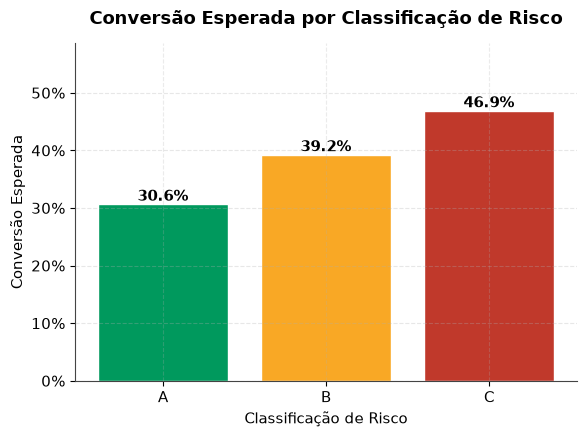

In [36]:
# ============================================================
# 12.2 CONVERSÃO ESPERADA POR CLASSIFICAÇÃO DE RISCO
# ============================================================

conversao = (
    op_tratado
    .groupby("Classificacao_Risco", observed=True)
    .agg(
        Conversao=("Taxa_Conversao", "mean")
    )
    .reset_index()
)

cores_conv = [
    CORES_RISCO.get(c, "#00995D")
    for c in conversao["Classificacao_Risco"]
]

fig, ax = plt.subplots(figsize=(6, 4.5))

barras = ax.bar(
    conversao["Classificacao_Risco"],
    conversao["Conversao"],
    color=cores_conv,
    edgecolor="white"
)

ax.set_title("Conversão Esperada por Classificação de Risco", pad=14)
ax.set_xlabel("Classificação de Risco")
ax.set_ylabel("Conversão Esperada")

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, conversao["Conversao"].max() * 1.25)
ax.grid(axis="y", alpha=.3)

for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{altura:.1%}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

> 💡 **Leitura do gráfico:** a conversão esperada cresce à medida que o risco aumenta — menor no risco **A** e mais alta no risco **C**. Uma hipótese razoável é que clientes de maior risco tenham menos alternativas de crédito disponíveis no mercado, aceitando condições menos favoráveis com maior frequência; já clientes de menor risco, com mais opções, tendem a ser mais seletivos mesmo diante de taxas mais baixas. Essa leitura é uma **hipótese a validar** com a área comercial, e não uma conclusão causal — vale como ponto de atenção para o desenho de futuras campanhas de oferta.

### 12.3 Resultado Esperado por Segmento (Risco x Grupo de Valor)

A terceira leitura é econômica: qual o retorno esperado de cada combinação de risco e grupo de valor, líquido de funding, inadimplência e ponderado pela conversão estimada?

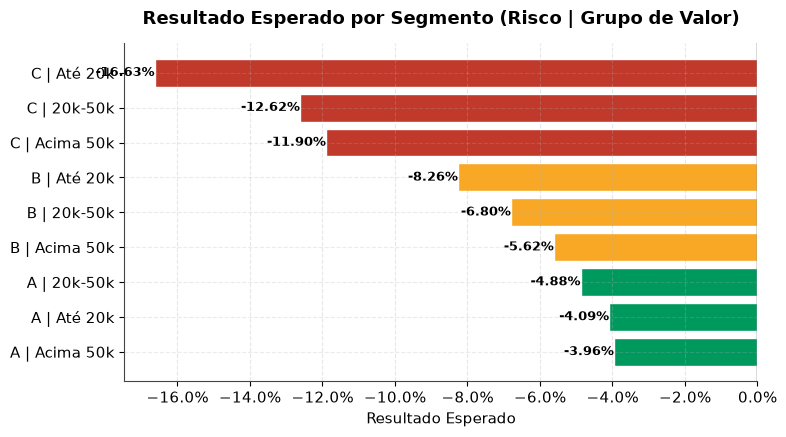

In [37]:
# ============================================================
# 12.3 RESULTADO ESPERADO POR SEGMENTO
# ============================================================

resultado_seg = (
    op_tratado
    .groupby(
        ["Classificacao_Risco", "Grupo_Valor"],
        observed=True
    )
    .agg(
        Resultado=("Resultado_Esperado", "mean")
    )
    .reset_index()
)

resultado_seg["Segmento"] = (
    resultado_seg["Classificacao_Risco"]
    + " | "
    + resultado_seg["Grupo_Valor"]
)

# Ordena do melhor para o pior resultado; como o barh desenha a primeira
# linha na base do gráfico, o pior segmento acaba destacado no topo.
resultado_seg = resultado_seg.sort_values("Resultado", ascending=False)

cores_result = [
    CORES_RISCO.get(c, "#00995D")
    for c in resultado_seg["Classificacao_Risco"]
]

fig, ax = plt.subplots(figsize=(8, 4.5))

barras = ax.barh(
    resultado_seg["Segmento"],
    resultado_seg["Resultado"],
    color=cores_result,
    edgecolor="white"
)

ax.axvline(0, color="#444444", linewidth=1)

ax.set_title("Resultado Esperado por Segmento (Risco | Grupo de Valor)", pad=14)
ax.set_xlabel("Resultado Esperado")

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="x", alpha=.3)

for barra in barras:
    largura = barra.get_width()
    ax.text(
        largura,
        barra.get_y() + barra.get_height()/2,
        f"{largura:.2%}",
        va="center",
        ha="right" if largura < 0 else "left",
        fontweight="bold",
        fontsize=9
    )

plt.tight_layout()
plt.show()

> ⚠️ **Ponto de atenção:** todos os segmentos apresentam **resultado esperado negativo** neste indicador, variando de aproximadamente **-4%** (risco A) a **-17%** (risco C, grupo "Até 20k"). Antes de qualquer conclusão comercial, é importante entender a causa — o que é feito na nota metodológica da seção 13.

### 12.4 Matriz Consolidada de Precificação

A política final, resumida na matriz de taxas por Classificação de Risco e Grupo de Valor:

In [38]:
# ============================================================
# 12.4 MATRIZ CONSOLIDADA DE PRECIFICAÇÃO
# ============================================================

politica_df = (
    op_tratado
    .groupby(
        ["Classificacao_Risco", "Grupo_Valor"],
        observed=True
    )["Taxa_Nova"]
    .mean()
    .unstack()
    .loc[:, ["Até 20k", "20k-50k", "Acima 50k"]]
)

display(
    politica_df.style
    .format("{:.0%}")
    .background_gradient(cmap="Greens", axis=None)
    .set_caption("Taxa de juros mensal proposta por segmento")
)

Grupo_Valor,Até 20k,20k-50k,Acima 50k
Classificacao_Risco,,,
A,3%,2%,2%
B,4%,3%,3%
C,6%,5%,5%


> ✅ A matriz confirma a lógica esperada: as taxas **crescem com o risco** (A → B → C) e **decrescem com o valor financiado** dentro de cada classificação — recompensando operações maiores, historicamente menos inadimplentes (seção 10.5).

### 12.5 Painel Consolidado por Faixa de Taxa

Por fim, um painel único cruza **volume**, **conversão** e **resultado esperado** para cada taxa proposta, servindo como resumo executivo da política.

In [39]:
# ============================================================
# 12.5 PAINEL CONSOLIDADO POR FAIXA DE TAXA
# ============================================================

painel = (
    op_tratado
    .groupby("Taxa_Nova", observed=True)
    .agg(
        Operacoes=("Id_Operacao", "count"),
        Conversao=("Taxa_Conversao", "mean"),
        Resultado=("Resultado_Esperado", "mean")
    )
    .reset_index()
)

painel["% Carteira"] = painel["Operacoes"] / painel["Operacoes"].sum()

display(
    painel.set_index("Taxa_Nova").style.format({
        "Operacoes": "{:,.0f}",
        "Conversao": "{:.1%}",
        "Resultado": "{:.2%}",
        "% Carteira": "{:.1%}"
    })
)

,Operacoes,Conversao,Resultado,% Carteira
Taxa_Nova,,,,
0.020000,"5,543",38.8%,-4.49%,18.9%
0.030000,"12,125",28.4%,-4.39%,41.3%
0.040000,"8,982",38.6%,-8.26%,30.6%
0.050000,222,47.0%,-12.41%,0.8%
0.060000,"2,511",46.8%,-16.63%,8.5%


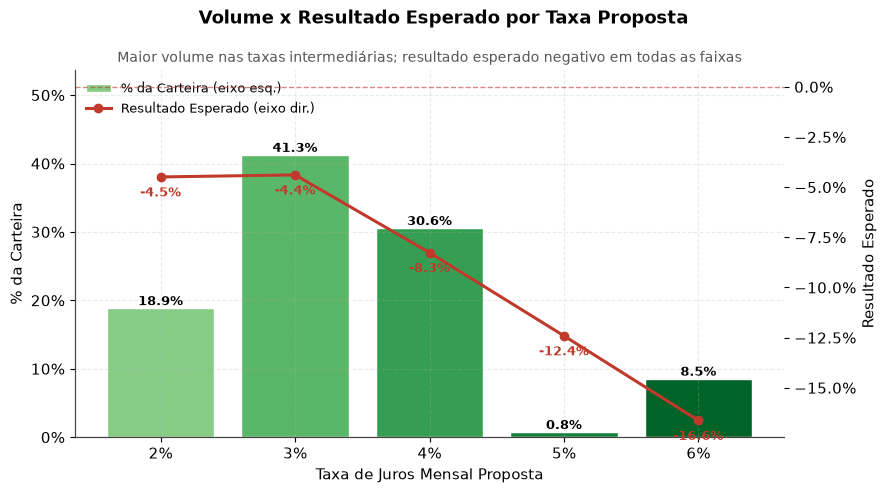

In [40]:
# ------------------------------------------------------------
# Gráfico combinado: volume (barras) x resultado esperado (linha)
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(9, 5))

x_labels = painel["Taxa_Nova"].map(lambda x: f"{x:.0%}")
cores_painel = plt.cm.Greens(np.linspace(0.45, 0.90, len(painel)))

barras = ax1.bar(
    x_labels,
    painel["% Carteira"],
    color=cores_painel,
    edgecolor="white",
    label="% da Carteira (eixo esq.)"
)

ax1.set_xlabel("Taxa de Juros Mensal Proposta")
ax1.set_ylabel("% da Carteira")
ax1.yaxis.set_major_formatter(PercentFormatter(1))
ax1.set_ylim(0, painel["% Carteira"].max() * 1.3)

for barra in barras:
    altura = barra.get_height()
    ax1.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f"{altura:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax2 = ax1.twinx()

ax2.plot(
    x_labels,
    painel["Resultado"],
    color="#C0392B",
    marker="o",
    linewidth=2.2,
    label="Resultado Esperado (eixo dir.)"
)

ax2.axhline(0, color="#C0392B", linestyle="--", linewidth=1, alpha=0.6)

ax2.set_ylabel("Resultado Esperado")
ax2.yaxis.set_major_formatter(PercentFormatter(1))
ax2.grid(False)

for xi, yi in zip(x_labels, painel["Resultado"]):
    ax2.annotate(
        f"{yi:.1%}",
        (xi, yi),
        textcoords="offset points",
        xytext=(0, -14),
        ha="center",
        fontsize=9,
        fontweight="bold",
        color="#C0392B"
    )

fig.suptitle(
    "Volume x Resultado Esperado por Taxa Proposta",
    fontsize=13,
    fontweight="bold"
)
ax1.set_title(
    "Maior volume nas taxas intermediárias; resultado esperado negativo em todas as faixas",
    fontsize=10,
    fontweight="normal",
    color="#555555"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

> 🎯 **Síntese da seção 12:** a política concentra volume nas faixas de risco/valor mais representativas da carteira e mantém uma lógica de precificação coerente com o risco. Ainda assim, o indicador de **Resultado Esperado é sistematicamente negativo** em todos os cortes analisados — volume, segmento e taxa. Esse padrão consistente (e não pontual) é o principal gatilho para a nota metodológica apresentada a seguir, na conclusão do case.

## 13. Conclusão do Case e Recomendações

Fechando o case, esta seção investiga o principal ponto de atenção identificado na seção 12 — o resultado esperado sistematicamente negativo —, sintetiza os achados de toda a análise e propõe os próximos passos.

### 13.1 Nota Metodológica — por que o Resultado Esperado é negativo em todos os segmentos

Vale investigar a raiz do padrão observado na seção 12.3: o `Resultado_Esperado` foi calculado, na seção 11.6, como:

$$\text{Resultado} = (\text{Taxa\_Nova} - \text{funding} - \text{Inadimplência}) \times \text{Taxa\_Conversão}$$

Nessa fórmula, `Taxa_Nova` e `funding` são taxas **mensais**, mas `Inadimplencia` é o **percentual histórico acumulado** da carteira — a mesma variável usada na análise exploratória, sem a amortização mensal. Na seção 11.1, esse ajuste já havia sido preparado (`Custo_Risco_Mensal = Inadimplencia / 24`, seguindo a premissa de crescimento linear da inadimplência ao longo de 24 meses), mas não chegou a ser aplicado na fórmula final do resultado esperado.

Como a inadimplência "cheia" costuma ser muito maior do que uma taxa de juros mensal, o termo `(Taxa_Nova - funding - Inadimplencia)` fica negativo mesmo nos segmentos de menor risco — o que explica o padrão sistemático observado no gráfico anterior.

Abaixo, uma verificação rápida: recalculamos o resultado esperado substituindo `Inadimplencia` por `Custo_Risco_Mensal`, **sem alterar a coluna original**, apenas para dimensionar o efeito do ajuste.

In [41]:
# ============================================================
# 13.1 VERIFICAÇÃO: EFEITO DO CUSTO DE RISCO AMORTIZADO
# ============================================================

op_tratado["Resultado_Esperado_Ajustado"] = (
    (
        op_tratado["Taxa_Nova"]
        - funding
        - op_tratado["Custo_Risco_Mensal"]
    )
    * op_tratado["Taxa_Conversao"]
)

comparativo = (
    op_tratado
    .groupby("Taxa_Nova", observed=True)
    .agg(
        Resultado_Original=("Resultado_Esperado", "mean"),
        Resultado_Ajustado=("Resultado_Esperado_Ajustado", "mean")
    )
)

display(
    comparativo.style.format("{:.2%}")
    .background_gradient(cmap="RdYlGn", axis=None)
    .set_caption("Resultado esperado: fórmula original x fórmula com custo de risco amortizado (1/24)")
)

,Resultado_Original,Resultado_Ajustado
Taxa_Nova,,
0.020000,-4.49%,0.12%
0.030000,-4.39%,0.31%
0.040000,-8.26%,0.70%
0.050000,-12.41%,1.21%
0.060000,-16.63%,1.47%


> 📌 **Recomendação:** caso a leitura acima confirme resultados majoritariamente positivos com o custo de risco amortizado, recomenda-se **adotar `Custo_Risco_Mensal` na métrica oficial de Resultado Esperado** (seção 11.6) nas próximas iterações do case, mantendo a métrica original apenas como referência do "pior cenário" (custo de risco integral em um único mês).

### 13.2 Síntese do Case

**O que foi feito.** A partir de três bases brutas — operações, inadimplência e conversão —, foi construída uma base analítica única (`op_tratado`), validada e enriquecida com variáveis de negócio. A análise exploratória (seção 10) identificou a **Classificação de Risco** (23,9 p.p. de amplitude de inadimplência) e a **Faixa de Valor Financiado** (17,4 p.p.) como os principais direcionadores de risco da carteira, superando variáveis como Perfil, Prazo, Idade e Tempo de Relacionamento (todas com amplitude inferior a 6 p.p.).

**O que foi proposto.** Com base nesses dois direcionadores, foi construída uma matriz de precificação com 9 combinações de taxa (3 níveis de risco x 3 grupos de valor), variando de **2% a 6% ao mês**. A política concentra cerca de **70% da carteira** nas taxas de 3% e 4%, refletindo o perfil predominante de risco A/B da base.

**O que exige atenção.** O indicador de Resultado Esperado, como calculado originalmente na seção 11.6, aponta retorno negativo em 100% dos segmentos — um sinal que, como discutido em 13.1, decorre muito provavelmente de uma inconsistência de unidades (inadimplência acumulada vs. taxa mensal) e não necessariamente de uma política mal calibrada. Este é o principal ponto de revisão antes de qualquer decisão de negócio baseada nesse indicador.

### 13.3 Recomendações para Próximos Passos

1. **Corrigir a métrica de resultado esperado**, substituindo a inadimplência acumulada pelo custo de risco mensal amortizado (seção 13.1), e reavaliar a atratividade econômica da política com a métrica corrigida.
2. **Monitorar o Nicho como variável candidata** a uma futura revisão da política — apresentou a segunda maior amplitude de inadimplência (20,5 p.p.), mas foi mantido fora da matriz nesta versão para preservar a simplicidade operacional (seção 10.4).
3. **Validar a hipótese de conversão crescente com o risco** (seção 12.2) junto à área comercial, antes de assumir esse padrão como estável para fins de precificação futura.
4. **Testar a política de forma controlada** (piloto ou A/B test) antes do rollout completo, já que a conversão estimada parte de dados históricos e pode não se repetir exatamente sob as novas taxas.
5. **Revisar periodicamente a matriz de taxas**, à medida que novos dados de inadimplência e conversão forem observados sob a política vigente, mantendo o modelo atualizado.